## Imports + versions

In [27]:
import site
site.addsitedir(site.getusersitepackages())

import numpy as np
import pandas as pd

import sklearn
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, auc, roc_curve

from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt

%matplotlib inline

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

import os
print(os.listdir("outputs_submission_fecalwater") if os.path.exists("outputs_submission_fecalwater") else "No folder yet")

pandas: 1.4.2
numpy: 1.22.3
sklearn: 1.7.2
No folder yet


## Load data

In [28]:
df = pd.read_csv("ListeriaSoil_clean.csv")
meta = pd.read_csv("ListeriaSoil_Metadata.csv")

print("df shape:", df.shape)
display(df.head(3))
display(meta.head(10))

df shape: (622, 35)


,Latitude,Longitude,Elevation (m),Moisture,Total nitrogen (%),Total carbon (%),pH,Organic matter (%),Aluminum (mg/Kg),Calcium (mg/Kg),...,Developed open space (< 20% Impervious Cover) (%),Developed open space (> 20% Impervious Cover) (%),Barren (%),Forest (%),Shrubland (%),Grassland (%),Cropland (%),Pasture (%),Wetland (%),Number of Listeria isolates obtained
0,35.4740,-83.8701,487.79,0.4280,0.2138,4.7973,4.639,7.3493,140.7795,73.6060,...,1.6472,0.1679,0.0275,94.9182,0.2783,0.1173,0.1530,0.0,0.0577,6.0
1,35.4850,-83.8675,584.73,0.4241,0.2226,5.0271,4.677,7.0913,116.8586,142.0197,...,1.4449,0.1331,0.0279,95.2959,0.3105,0.1056,0.1136,0.0,0.0577,4.0
2,35.4815,-83.8587,779.80,0.4425,0.2198,7.4885,4.102,11.5970,126.6213,153.0297,...,1.4779,0.1346,0.0317,95.1514,0.2998,0.1073,0.1415,0.0,0.0577,6.0


,Variable,Description,Type
0,Latitude,Latitude of the sampling location,Predictor
1,Longitude,Longitude of the sampling location,Predictor
2,Elevation (m),Elevation (m) of the sampling location obtaine...,Predictor
3,Moisture,Moisture measure using Methods of Soil Analysi...,Predictor
4,Total nitrogen (%),Total nitrogen of the soil sample,Predictor
5,Total carbon (%),Total carbon of the soil sample,Predictor
6,pH,pH of the soil sample,Predictor
7,Organic matter (%),Organic matter of the soil sample,Predictor
8,Aluminum (mg/Kg),Aluminum of the soil sample,Predictor
9,Calcium (mg/Kg),Calcium of the soil sample,Predictor


## Create target and features

In [29]:
TARGET_COUNT = "Number of Listeria isolates obtained"

df["y"] = (df[TARGET_COUNT] > 0).astype(int)

print("Class balance:")
print(df["y"].value_counts())
print("Positive rate:", df["y"].mean())

X = df.drop(columns=[TARGET_COUNT, "y"])
y = df["y"].values

print("X shape:", X.shape)

Class balance:
1    311
0    311
Name: y, dtype: int64
Positive rate: 0.5
X shape: (622, 34)


## Sanity checks

In [30]:
print("Any missing values?", X.isna().any().any())
print("Dtypes:")
print(X.dtypes.value_counts())

assert "Latitude" in X.columns and "Longitude" in X.columns

Any missing values? False
Dtypes:
float64    34
dtype: int64


## Metrics + threshold helpers

In [31]:
def pr_auc_score(y_true, y_prob):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    return auc(r, p)

def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def tune_threshold_for_f1(y_true, y_prob, t_min=0.05, t_max=0.95, steps=181):
    ts = np.linspace(t_min, t_max, steps)
    best_t, best_f1 = 0.5, -1.0
    for t in ts:
        f1 = f1_score(y_true, (y_prob >= t).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, float(best_f1)

def summarize_probs(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": pr_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
    }
    sens, spec = sensitivity_specificity(y_true, y_pred)
    out["sensitivity"] = sens
    out["specificity"] = spec
    out["threshold"] = float(threshold)
    return out

## Spatial grouping helper

In [32]:
def make_spatial_groups(df_features, grid_size_deg):
    lat_bin = np.floor(df_features["Latitude"].astype(float) / grid_size_deg).astype(int)
    lon_bin = np.floor(df_features["Longitude"].astype(float) / grid_size_deg).astype(int)
    return (lat_bin.astype(str) + "_" + lon_bin.astype(str)).values

## Evaluation lock

In [33]:
EVAL = dict(
    dataset="ListeriaSoil_clean.csv",
    target_definition="y = 1 if isolates_obtained > 0 else 0",
    cv="StratifiedGroupKFold",
    grid_size_deg=0.25,
    n_splits=5,
    seed=42,
    threshold_policy="max_f1_oof",
)

groups_eval = make_spatial_groups(X, grid_size_deg=EVAL["grid_size_deg"])

try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv_eval = StratifiedGroupKFold(
        n_splits=EVAL["n_splits"],
        shuffle=True,
        random_state=EVAL["seed"],
    )
    splits_eval = list(cv_eval.split(X, y, groups_eval))
    print("Using StratifiedGroupKFold")
except Exception as e:
    from sklearn.model_selection import GroupKFold
    cv_eval = GroupKFold(n_splits=EVAL["n_splits"])
    splits_eval = list(cv_eval.split(X, y, groups_eval))
    EVAL["cv"] = "GroupKFold_fallback"
    print("StratifiedGroupKFold not available, using GroupKFold fallback")

g = pd.Series(groups_eval)
print("Locked EVAL:", EVAL)
print("Num groups:", g.nunique())
print("Group size summary:")
display(g.value_counts().describe())
print("Num splits:", len(splits_eval))

Using StratifiedGroupKFold
Locked EVAL: {'dataset': 'ListeriaSoil_clean.csv', 'target_definition': 'y = 1 if isolates_obtained > 0 else 0', 'cv': 'StratifiedGroupKFold', 'grid_size_deg': 0.25, 'n_splits': 5, 'seed': 42, 'threshold_policy': 'max_f1_oof'}
Num groups: 210
Group size summary:


count    210.000000
mean       2.961905
std        1.603965
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       10.000000
dtype: float64

Num splits: 5


## Model lock (CatBoost params)

In [34]:
CAT_PARAMS = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=20000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=EVAL["seed"],
    allow_writing_files=False,
    verbose=200,
    od_type="Iter",
    od_wait=300,
)

## CatBoost CV with OOF + tuned threshold

In [35]:
def run_catboost_cv_oof(X, y, splits, label):
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    oof = np.zeros(len(y), dtype=float)
    fold_rows_t05 = []

    for fold, (tr, va) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
        valid_pool = Pool(X_va, y_va, cat_features=cat_idx)

        model = CatBoostClassifier(**CAT_PARAMS)
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        va_prob = model.predict_proba(valid_pool)[:, 1]
        oof[va] = va_prob

        m05 = summarize_probs(y_va, va_prob, threshold=0.5)
        m05["fold"] = fold
        m05["cv_type"] = label
        fold_rows_t05.append(m05)

        print(f"[{label} fold {fold}] AUC={m05['roc_auc']:.4f} F1@0.5={m05['f1']:.4f}")

    best_t, best_f1 = tune_threshold_for_f1(y, oof)
    overall = summarize_probs(y, oof, threshold=best_t)
    overall["best_f1_objective"] = best_f1
    overall["cv_type"] = label

    # fold metrics at tuned threshold
    fold_rows_tbest = []
    for fold, (_, va) in enumerate(splits, start=1):
        m = summarize_probs(y[va], oof[va], threshold=best_t)
        m["fold"] = fold
        m["cv_type"] = label
        fold_rows_tbest.append(m)

    folds_t05 = pd.DataFrame(fold_rows_t05)
    folds_tbest = pd.DataFrame(fold_rows_tbest)

    return oof, folds_t05, folds_tbest, overall

oof_final, folds_t05, folds_tbest, overall_final = run_catboost_cv_oof(
    X, y, splits_eval, label="FINAL"
)

print("\nOVERALL (tuned threshold):")
print(overall_final)

print("\nFold mean ± std at tuned threshold:")
display(folds_tbest[["roc_auc","pr_auc","f1","sensitivity","specificity"]].agg(["mean","std"]).T)

0:	test: 0.7602679	best: 0.7602679 (0)	total: 31.8ms	remaining: 10m 36s
200:	test: 0.9169643	best: 0.9202381 (104)	total: 937ms	remaining: 1m 32s
400:	test: 0.9258929	best: 0.9264881 (383)	total: 1.97s	remaining: 1m 36s
600:	test: 0.9300595	best: 0.9306548 (562)	total: 2.98s	remaining: 1m 36s
800:	test: 0.9309524	best: 0.9315476 (673)	total: 4.1s	remaining: 1m 38s
1000:	test: 0.9324405	best: 0.9330357 (984)	total: 5.25s	remaining: 1m 39s
1200:	test: 0.9321429	best: 0.9333333 (1009)	total: 6.28s	remaining: 1m 38s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9333333333
bestIteration = 1009

Shrink model to first 1010 iterations.
[FINAL fold 1] AUC=0.9333 F1@0.5=0.8780
0:	test: 0.7169989	best: 0.7169989 (0)	total: 5.33ms	remaining: 1m 46s
200:	test: 0.8914332	best: 0.8914332 (198)	total: 898ms	remaining: 1m 28s
400:	test: 0.8997845	best: 0.9011315 (380)	total: 1.86s	remaining: 1m 30s
600:	test: 0.9024784	best: 0.9032866 (585)	total: 2.76s	remaining: 1m 29s
800:	tes

,mean,std
roc_auc,0.935938,0.022088
pr_auc,0.934960,0.027356
f1,0.869493,0.034788
sensitivity,0.894663,0.035616
specificity,0.837609,0.040194


## Threshold sweep

In [36]:
def threshold_sweep(y_true, y_prob, ts=np.linspace(0.1, 0.9, 17)):
    rows = []
    for t in ts:
        rows.append(summarize_probs(y_true, y_prob, threshold=float(t)))
    return pd.DataFrame(rows).sort_values("f1", ascending=False)

sweep = threshold_sweep(y, oof_final)
display(sweep.head(10))

,roc_auc,pr_auc,f1,sensitivity,specificity,threshold
7,0.936157,0.932398,0.870370,0.906752,0.823151,0.45
6,0.936157,0.932398,0.866769,0.909968,0.810289,0.40
8,0.936157,0.932398,0.866562,0.887460,0.839228,0.50
11,0.936157,0.932398,0.861386,0.839228,0.890675,0.65
9,0.936157,0.932398,0.861244,0.868167,0.852090,0.55
10,0.936157,0.932398,0.860841,0.855305,0.868167,0.60
5,0.936157,0.932398,0.854599,0.926045,0.758842,0.35
4,0.936157,0.932398,0.853801,0.938907,0.739550,0.30
12,0.936157,0.932398,0.852349,0.816720,0.900322,0.70
3,0.936157,0.932398,0.844508,0.951768,0.697749,0.25


## Plots (ROC, PR, confusion matrix at tuned threshold)

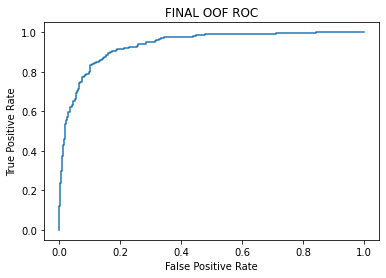

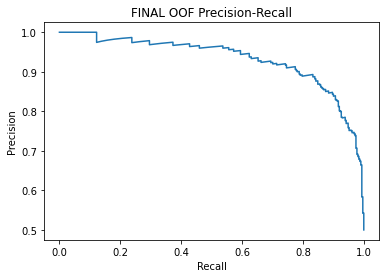

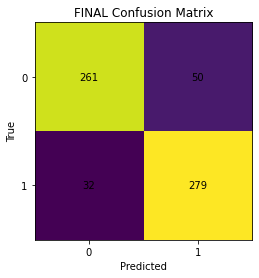

In [37]:
def plot_curves(y_true, y_prob, title_prefix=""):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    p, r, _ = precision_recall_curve(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC")
    plt.show()

    plt.figure()
    plt.plot(r, p)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall")
    plt.show()

def plot_confusion(y_true, y_prob, threshold, title=""):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_curves(y, oof_final, title_prefix="FINAL OOF")
plot_confusion(y, oof_final, overall_final["threshold"], title="FINAL Confusion Matrix")

##  Train final model on full data + feature importance

In [38]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

full_pool = Pool(X, y, cat_features=cat_idx)

final_model = CatBoostClassifier(**CAT_PARAMS)
final_model.fit(full_pool)

importances = final_model.get_feature_importance(full_pool)
imp_df = pd.DataFrame({"feature": X.columns, "importance": importances}).sort_values("importance", ascending=False)

display(imp_df.head(20))

0:	total: 10.9ms	remaining: 3m 37s
200:	total: 1.61s	remaining: 2m 38s
400:	total: 3.19s	remaining: 2m 36s
600:	total: 5s	remaining: 2m 41s
800:	total: 6.72s	remaining: 2m 40s
1000:	total: 8.39s	remaining: 2m 39s
1200:	total: 9.96s	remaining: 2m 35s
1400:	total: 11.9s	remaining: 2m 37s
1600:	total: 13.6s	remaining: 2m 36s
1800:	total: 15.2s	remaining: 2m 33s
2000:	total: 16.8s	remaining: 2m 31s
2200:	total: 18.6s	remaining: 2m 30s
2400:	total: 20.4s	remaining: 2m 29s
2600:	total: 22s	remaining: 2m 27s
2800:	total: 23.9s	remaining: 2m 26s
3000:	total: 25.6s	remaining: 2m 24s
3200:	total: 27s	remaining: 2m 21s
3400:	total: 28.5s	remaining: 2m 19s
3600:	total: 30.1s	remaining: 2m 17s
3800:	total: 31.8s	remaining: 2m 15s
4000:	total: 33.8s	remaining: 2m 15s
4200:	total: 35.4s	remaining: 2m 13s
4400:	total: 36.9s	remaining: 2m 10s
4600:	total: 38.7s	remaining: 2m 9s
4800:	total: 40.4s	remaining: 2m 8s
5000:	total: 42s	remaining: 2m 5s
5200:	total: 43.4s	remaining: 2m 3s
5400:	total: 44.8s	r

,feature,importance
16,Sodium (mg/Kg),18.320194
15,Molybdenum (mg/Kg),8.662675
3,Moisture,7.348143
10,Copper (mg/Kg),5.819529
12,Potassium (mg/Kg),4.206132
1,Longitude,4.161513
17,Phosphorus (mg/Kg),3.618273
19,Zinc (mg/Kg),3.594348
13,Magnesium (mg/Kg),3.498814
14,Manganese (mg/Kg),3.015507


##  Save outputs for submission

In [39]:
import os, json

OUT_DIR = "outputs_submission"
os.makedirs(OUT_DIR, exist_ok=True)

# Save evaluation lock and package versions
with open(f"{OUT_DIR}/eval_lock.json", "w") as f:
    json.dump(EVAL, f, indent=2)

with open(f"{OUT_DIR}/versions.json", "w") as f:
    json.dump(
        {"pandas": pd.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__},
        f,
        indent=2
    )

# Save metrics
with open(f"{OUT_DIR}/overall_metrics.json", "w") as f:
    json.dump(overall_final, f, indent=2)

folds_t05.to_csv(f"{OUT_DIR}/cv_fold_metrics_threshold_0p5.csv", index=False)
folds_tbest.to_csv(f"{OUT_DIR}/cv_fold_metrics_threshold_tuned.csv", index=False)

pd.DataFrame({"y": y, "oof_prob": oof_final}).to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)
imp_df.to_csv(f"{OUT_DIR}/feature_importance.csv", index=False)

# Save model
final_model.save_model(f"{OUT_DIR}/catboost_fullfit.cbm")

print("Saved outputs to:", OUT_DIR)

Saved outputs to: outputs_submission


## Calibration + decision policy

In [40]:
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

oof_df = pd.read_csv("outputs_submission/oof_predictions.csv")
y_true = oof_df["y"].astype(int).values
p_raw = oof_df["oof_prob"].astype(float).values

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_raw, y_true)
p_cal = iso.transform(p_raw)

print("Brier (raw):", brier_score_loss(y_true, p_raw))
print("Brier (cal):", brier_score_loss(y_true, p_cal))

Brier (raw): 0.10078418347858246
Brier (cal): 0.09451296101669783


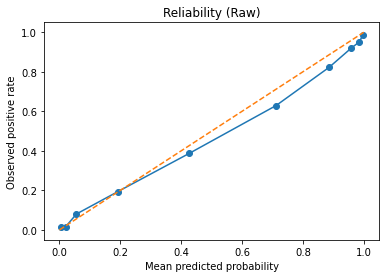

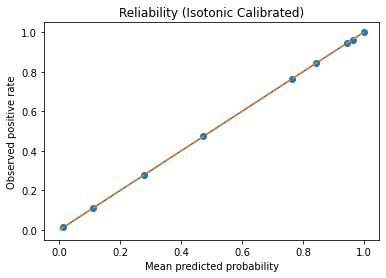

In [41]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_reliability(y_true, p, title):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.show()

plot_reliability(y_true, p_raw, "Reliability (Raw)")
plot_reliability(y_true, p_cal, "Reliability (Isotonic Calibrated)")